### Primeros pasos

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
vendidos = pd.read_csv('.\sales.csv')
vendidos = vendidos.drop(columns = 'Rank')
vendidos.head(10)

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [23]:
vendidos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Name          16598 non-null  object 
 1   Platform      16598 non-null  object 
 2   Year          16327 non-null  float64
 3   Genre         16598 non-null  object 
 4   Publisher     16540 non-null  object 
 5   NA_Sales      16598 non-null  float64
 6   EU_Sales      16598 non-null  float64
 7   JP_Sales      16598 non-null  float64
 8   Other_Sales   16598 non-null  float64
 9   Global_Sales  16598 non-null  float64
dtypes: float64(6), object(4)
memory usage: 1.3+ MB


### Limpieza de datos

In [24]:
vendidos.isnull().sum()

Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [25]:
vendidos[vendidos.isnull().any(axis=1)]

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,NaN,1.57,1.02,0.00,0.41,3.00
607,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...
16427,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01
16493,The Smurfs,3DS,NaN,Action,Unknown,0.00,0.01,0.00,0.00,0.01
16494,Legends of Oz: Dorothy's Return,3DS,2014.0,Puzzle,NaN,0.00,0.01,0.00,0.00,0.01
16543,Driving Simulator 2011,PC,2011.0,Racing,NaN,0.00,0.01,0.00,0.00,0.01


In [26]:
vendidos['Year'] = vendidos['Year'].ffill()

In [27]:
vendidos['Publisher'] = vendidos['Publisher'].bfill()

In [28]:
vendidos.isnull().sum()

Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

### Exploracion de datos

In [29]:
vendidos.describe()

,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,2006.409326,0.264667,0.146652,0.077782,0.048063,0.537441
std,5.820108,0.816683,0.505351,0.309291,0.188588,1.555028
min,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [30]:
vendidos['Platform'].value_counts()

Platform
DS      2163
PS2     2161
PS3     1329
Wii     1325
X360    1265
PSP     1213
PS      1196
PC       960
XB       824
GBA      822
GC       556
3DS      509
PSV      413
PS4      336
N64      319
SNES     239
XOne     213
SAT      173
WiiU     143
2600     133
NES       98
GB        98
DC        52
GEN       27
NG        12
SCD        6
WS         6
3DO        3
TG16       2
GG         1
PCFX       1
Name: count, dtype: int64

In [31]:
vendidos['Genre'].value_counts()

Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64

In [32]:
vendidos['Publisher'].value_counts()

Publisher
Electronic Arts                 1358
Activision                       978
Namco Bandai Games               935
Ubisoft                          924
Konami Digital Entertainment     835
                                ... 
Warp                               1
New                                1
Elite                              1
Evolution Games                    1
UIG Entertainment                  1
Name: count, Length: 578, dtype: int64

### Graficación

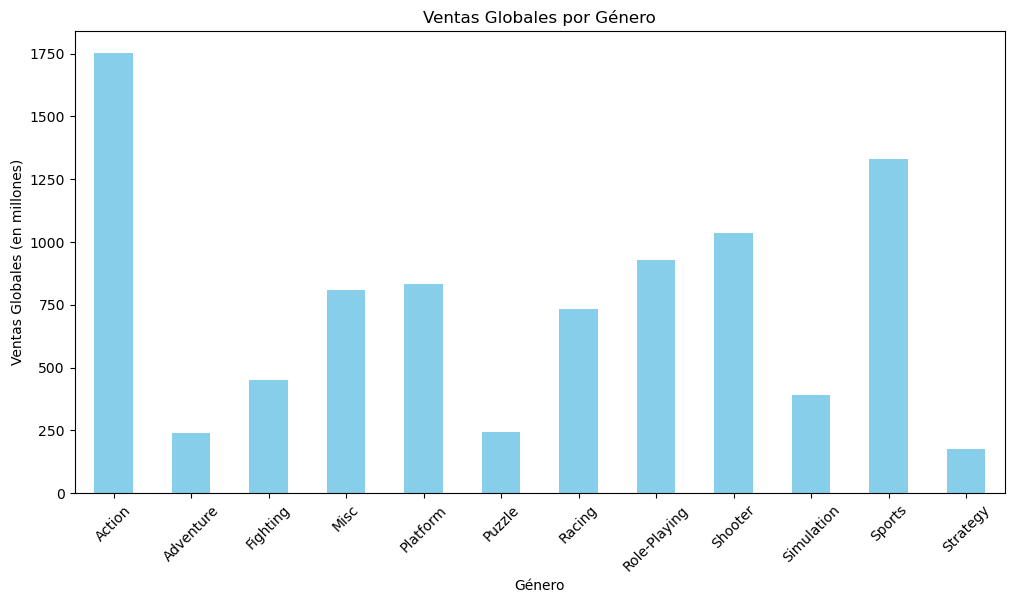

In [33]:
ventas_por_genero = vendidos.groupby('Genre')['Global_Sales'].sum()

plt.figure(figsize=(12, 6))
ventas_por_genero.plot(kind = 'bar', color = 'skyblue')
plt.title('Ventas Globales por Género')
plt.xlabel('Género')
plt.ylabel('Ventas Globales (en millones)')
plt.xticks(rotation = 45)
plt.show()

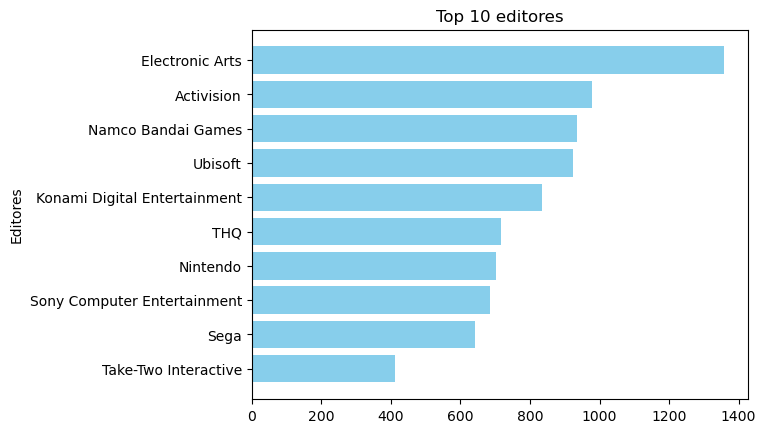

In [34]:
publisher = vendidos['Publisher'].value_counts()
publishers_top = publisher.sort_values(ascending=False).head(10)
publishers_top = publishers_top[::-1]

x = publishers_top.values
y = publishers_top.index

plt.barh(y, x, color='skyblue')
plt.ylabel('Editores')
plt.title('Top 10 editores')
plt.show()

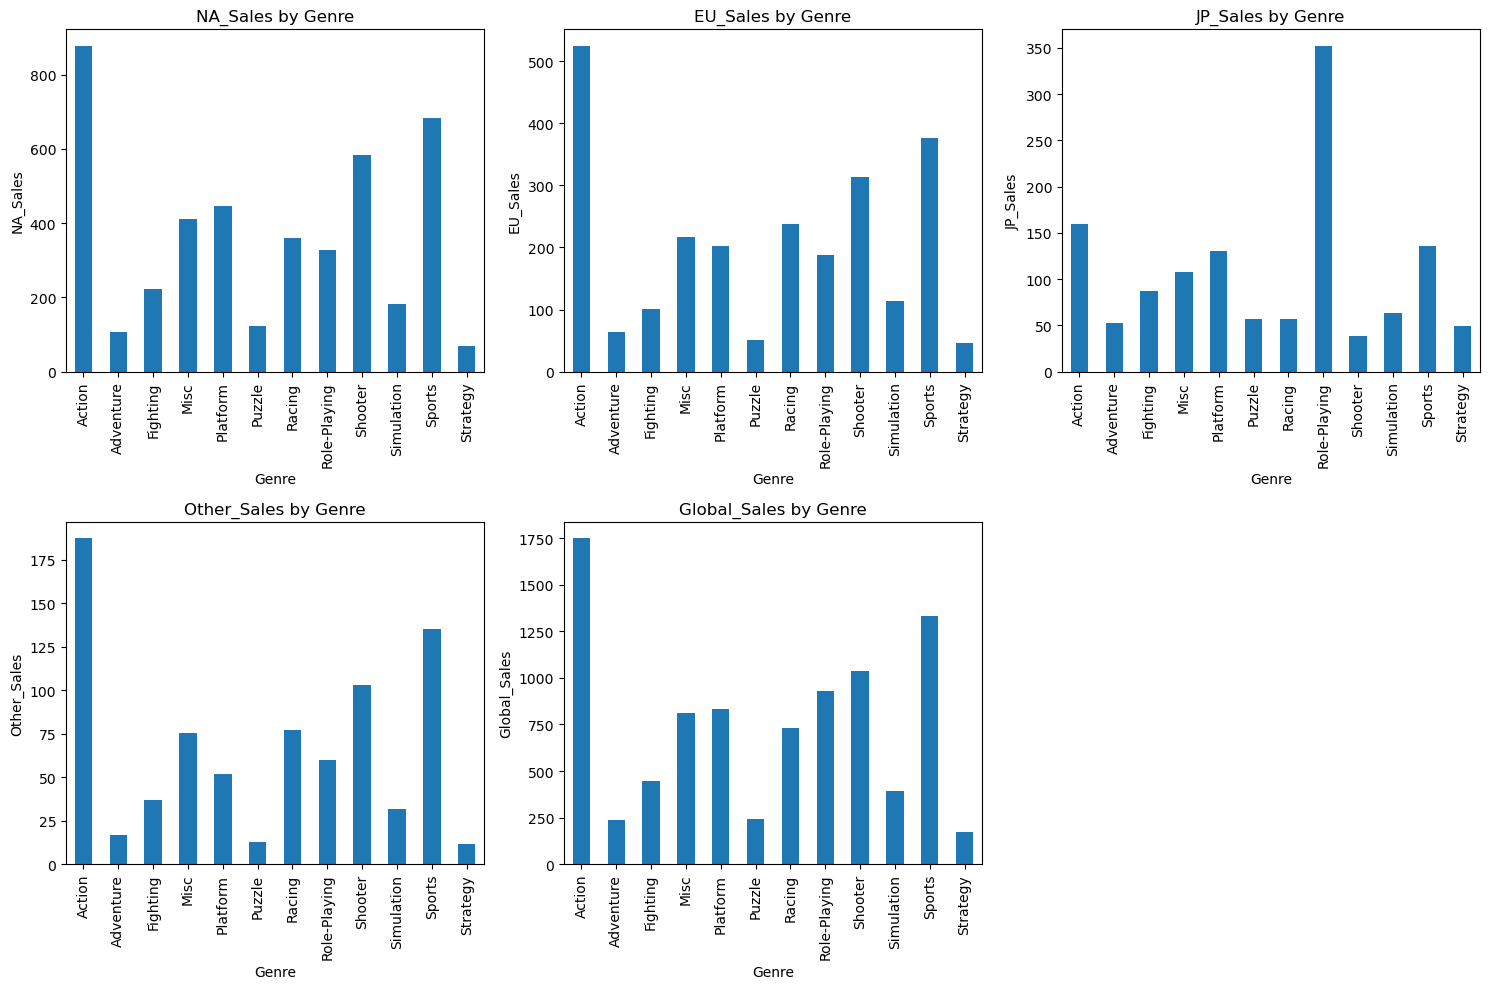

In [14]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
na_sizes = vendidos.groupby('Genre')['NA_Sales'].sum()
na_sizes.plot(kind='bar')
plt.xlabel('Genre')
plt.ylabel('NA_Sales')
plt.title('NA_Sales by Genre')

plt.subplot(2, 3, 2)
eu_sizes = vendidos.groupby('Genre')['EU_Sales'].sum()
eu_sizes.plot(kind='bar')
plt.xlabel('Genre')
plt.ylabel('EU_Sales')
plt.title('EU_Sales by Genre')

plt.subplot(2, 3, 3)
jp_sizes = vendidos.groupby('Genre')['JP_Sales'].sum()
jp_sizes.plot(kind='bar')
plt.xlabel('Genre')
plt.ylabel('JP_Sales')
plt.title('JP_Sales by Genre')

plt.subplot(2, 3, 4)
other_sizes = vendidos.groupby('Genre')['Other_Sales'].sum()
other_sizes.plot(kind='bar')
plt.xlabel('Genre')
plt.ylabel('Other_Sales')
plt.title('Other_Sales by Genre')

plt.subplot(2, 3, 5)
global_sizes = vendidos.groupby('Genre')['Global_Sales'].sum()
global_sizes.plot(kind='bar')
plt.xlabel('Genre')
plt.ylabel('Global_Sales')
plt.title('Global_Sales by Genre')

plt.tight_layout()
plt.show()

### Conclusión

1. El género de videojuegos que más se ha vendido ha sido el de acción.

2. Al tener varias gráficas, podemos obtener distintas respuestas, como por ejemplo:
   * En América del Norte se venden más los juegos de acción, al igual que en Europa.
   * En Japón, los más vendidos son los juegos de rol.
   * En los demás países, los más vendidos son los de acción.

3. La consola de videojuegos que más juegos vendió fue la PS2 (PlayStation 2).